# Notebook 09 — MTDA: Multi-Target Domain Adaptation

Extends the single-target DANN (FD001 → AI4I) to **multiple target domains simultaneously**.

## Architecture
```
Source FD001 ─────────────────────────────────────────► [Shared CNN-BiLSTM backbone]
                                                                     │
Target AI4I  → [Polarity aligner] → [Adapter_AI4I]  ───────────────►│──► RUL regressor
Target FD003 → [Polarity aligner] → [Adapter_FD003] ───────────────►│
                                                                     │
                                                         [Multi-class domain discriminator]
                                                          (0=FD001, 1=AI4I, 2=FD003)
```

## Compatibility with fixed NB04-06
- Backbone is CNN-BiLSTM-Deep from NB04 (24-dim FD001 features, w=50)
- Each target domain has its own 5-dim polarity-aligned adapter
- FD003 uses cluster-wise scaling (6 operating conditions)
- MTDA trainer uses the same phased training approach as NB05

In [51]:
# ── CELL 2: Imports & Setup ───────────────────────────────────────────────────
import sys, os
sys.path.append(os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras import layers, Model, Input
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import MinMaxScaler
from sklearn.cluster         import KMeans
from sklearn.manifold        import TSNE
from scipy.signal            import savgol_filter

from src.data_loader   import load_all_datasets, FEATURE_COLS, SENSOR_COLS
from src.preprocessor  import full_preprocess_pipeline
from src.windowing     import create_windows, create_windows_inference
from src.models.grl    import GradientReversalLayer
from src.evaluate      import rmse, mae

tf.random.set_seed(42)
np.random.seed(42)

WINDOW_SIZE    = 30
MAX_RUL        = 125
DANN_N_FEAT    = 5
ADAPTER_DIM    = 16
SOURCE_DS      = 'FD001'

AI4I_SENSOR_COLS = [
    'Air temperature [K]', 'Process temperature [K]',
    'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]'
]

os.makedirs('../models/saved', exist_ok=True)
print(f'MTDA setup. Source={SOURCE_DS}, n_features_shared={DANN_N_FEAT}')


MTDA setup. Source=FD001, n_features_shared=5


In [52]:
# ── CELL 3: Shared architecture definitions ───────────────────────────────────


def build_deeper_adapter(window_size, n_features, hidden_dim, name='adapter'):
    """Per-target domain adapter: 5→Dense(hidden,relu)→Dense(5)+skip."""
    inp      = Input(shape=(window_size, n_features), name=f'{name}_input')
    x        = layers.TimeDistributed(
                   layers.Dense(hidden_dim, activation='relu',
                                name=f'{name}_hidden'),
                   name=f'{name}_td_hidden')(inp)
    out_proj = layers.TimeDistributed(
                   layers.Dense(n_features, use_bias=False,
                                kernel_initializer='zeros',
                                name=f'{name}_out'),
                   name=f'{name}_td_out')(x)
    out      = layers.Add(name=f'{name}_residual')([inp, out_proj])
    return Model(inputs=inp, outputs=out, name=f'Adapter_{name}')


def build_mtda_model(window_size, n_features, n_domains,
                      filters, kernel_size, lstm_units,
                      feature_dim, reg_units, domain_units,
                      dropout=0.2):
    """
    Multi-Target DANN with n_domains-class discriminator.
    Source = class 0, Target_i = class i.

    Returns: (reg_model, mtda_model)
    """
    inp = Input(shape=(window_size, n_features), name='mtda_input')

    # ── Shared feature extractor (same CNN-LSTM as NB05) ──────────────────
    x = layers.Conv1D(filters[0], kernel_size, padding='same',
                      activation='relu', name='conv1')(inp)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.Conv1D(filters[1], kernel_size, strides=2, padding='same',
                      activation='relu', name='conv2')(x)
    x = layers.BatchNormalization(name='bn2')(x)
    x = layers.Dropout(dropout, name='cnn_drop')(x)
    x = layers.Bidirectional(
            layers.LSTM(lstm_units, return_sequences=True), name='bilstm_1')(x)
    x = layers.Bidirectional(
            layers.LSTM(lstm_units // 2, return_sequences=False), name='bilstm_2')(x)
    x = layers.Dropout(dropout, name='lstm_drop')(x)

    # Feature embedding
    feat = layers.Dense(feature_dim, activation='relu', name='feature_layer')(x)

    # ── RUL regressor ─────────────────────────────────────────────────────
    r = feat
    for i, u in enumerate(reg_units):
        r = layers.Dense(u, activation='relu', name=f'reg_{i}')(r)
        r = layers.Dropout(dropout, name=f'reg_drop_{i}')(r)
    rul_out = layers.Dense(1, name='rul_output')(r)

    # ── Multi-class domain discriminator via GRL ──────────────────────────
    grl = GradientReversalLayer(alpha=0.0, name='grl')(feat)
    d   = grl
    for i, u in enumerate(domain_units):
        d = layers.Dense(u, activation='relu', name=f'dom_{i}')(d)
        d = layers.Dropout(dropout, name=f'dom_drop_{i}')(d)
    # Softmax over n_domains classes (not sigmoid — multi-class discriminator)
    dom_out = layers.Dense(n_domains, activation='softmax',
                           name='domain_output')(d)

    mtda_model = Model(inputs=inp, outputs=[rul_out, dom_out], name='MTDA')
    reg_model  = Model(inputs=inp, outputs=rul_out,            name='MTDA_Regressor')
    return reg_model, mtda_model


print('MTDA architecture builders ready.')


MTDA architecture builders ready.


In [53]:
# ── CELL 4: Load and prepare source domain (FD001, top-5 features) ────────────
datasets = load_all_datasets(data_dir='../data/raw')

df_tr_src, _, scaler_src = full_preprocess_pipeline(
    df_train         = datasets['FD001']['train'],
    df_test          = datasets['FD001']['test'],
    feature_cols     = FEATURE_COLS,
    sensor_cols      = SENSOR_COLS,
    smooth           = True,
    max_rul          = MAX_RUL,
    scaler_save_path = '../models/saved/scaler_FD001.joblib'
)

# Select top-5 FD001 features by |corr with RUL| (same as NB05)
corr_src     = np.array([
    np.corrcoef(df_tr_src[c].values, df_tr_src['RUL'].values)[0, 1]
    for c in FEATURE_COLS
])
TOP5_IDX     = np.argsort(np.abs(corr_src))[::-1][:DANN_N_FEAT]
TOP5_COLS    = [FEATURE_COLS[i] for i in TOP5_IDX]
SRC_POLARITY = np.sign(corr_src[TOP5_IDX])

print(f'Source top-5: {TOP5_COLS}')

X_src_all, y_src_raw, _ = create_windows(df_tr_src, FEATURE_COLS, window_size=WINDOW_SIZE)
X_src = X_src_all[:, :, TOP5_IDX].astype(np.float32)
y_src = (y_src_raw / MAX_RUL).astype(np.float32)

X_src_tr, X_src_val, y_src_tr, y_src_val = train_test_split(
    X_src, y_src, test_size=0.1, random_state=42
)
print(f'Source: train={X_src_tr.shape}  val={X_src_val.shape}')


Source top-5: ['op_setting_3', 'sensor_4', 'sensor_11', 'sensor_15', 'sensor_21']
Source: train=(15867, 30, 5)  val=(1764, 30, 5)


/Users/skytan/ml/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/skytan/ml/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [54]:
# ── CELL 5: Polarity alignment helper (shared by all target domains) ──────────


def align_target_domain(X_raw, sensor_names, src_polarity,
                         rul_proxy=None, n_features=5):
    """
    Standard target domain preprocessing pipeline:
      1. MinMaxScaler to [0,1]
      2. Compute polarity vs RUL proxy
      3. Flip features where polarity differs from source

    Returns: (X_aligned, scaler, flip_mask, tgt_polarity)
    """
    scaler    = MinMaxScaler()
    X_scaled  = scaler.fit_transform(X_raw.astype(np.float32))

    if rul_proxy is None:
        # Fallback: assume last feature is a wear/degradation proxy
        rul_proxy = -X_scaled[:, -1]   # negative wear ≈ RUL direction

    corr_tgt    = np.array([
        np.corrcoef(X_scaled[:, i], rul_proxy)[0, 1]
        for i in range(n_features)
    ])
    tgt_polarity = np.sign(corr_tgt)
    flip_mask    = (src_polarity != tgt_polarity)

    X_aligned = X_scaled.copy()
    for i in range(n_features):
        if flip_mask[i]:
            X_aligned[:, i] = 1.0 - X_aligned[:, i]

    print(f'  Polarity flips: {flip_mask.astype(int).tolist()}')
    return X_aligned, scaler, flip_mask, tgt_polarity


def segment_by_wear_reset(df_raw, wear_col='Tool wear [min]'):
    df = df_raw.copy().reset_index(drop=True)
    run_id, cycle_id = 0, 1
    run_ids, cycle_ids = [], []
    for i in range(len(df)):
        if i > 0 and df[wear_col].iloc[i] < df[wear_col].iloc[i - 1]:
            run_id += 1; cycle_id = 1
        run_ids.append(run_id); cycle_ids.append(cycle_id); cycle_id += 1
    df['unit_id'] = run_ids; df['cycle'] = cycle_ids
    return df


print('Polarity alignment helper ready.')


Polarity alignment helper ready.


In [55]:
# ── CELL 6: Load and align target domains ─────────────────────────────────────
#
# Target 1: AI4I (5 factory sensors)
# Target 2: FD003 (same C-MAPSS but different operating conditions)
# Each gets its own adapter and polarity alignment.

target_windows = {}   # {domain_name: X_tgt array (N, 30, 5)}
target_meta    = {}   # {domain_name: {scaler, flip_mask, feature_cols}}

# ── Target 1: AI4I ───────────────────────────────────────────────────────────
print('Processing Target 1: AI4I')
ai4i_raw       = pd.read_csv('../data/raw/ai4i2020.csv')
ai4i_segmented = segment_by_wear_reset(ai4i_raw)

# Build RUL proxy for polarity calculation
mw_tmp = ai4i_segmented.groupby('unit_id')['Tool wear [min]'].max().rename('mw')
ai4i_s = ai4i_segmented.merge(mw_tmp, on='unit_id')
ai4i_rul_proxy = (ai4i_s['mw'] - ai4i_s['Tool wear [min]']).clip(upper=MAX_RUL).values

X_ai4i_aligned, ai4i_scaler, ai4i_flip, _ = align_target_domain(
    X_raw       = ai4i_raw[AI4I_SENSOR_COLS].values,
    sensor_names= AI4I_SENSOR_COLS,
    src_polarity= SRC_POLARITY,
    rul_proxy   = ai4i_rul_proxy
)
ai4i_cols = [f'ai4i_{i}' for i in range(DANN_N_FEAT)]
df_ai4i   = pd.DataFrame(X_ai4i_aligned, columns=ai4i_cols)
df_ai4i['unit_id'] = ai4i_segmented['unit_id'].values
df_ai4i['cycle']   = ai4i_segmented['cycle'].values
df_ai4i['RUL']     = 0.5
X_tgt_ai4i, _, _  = create_windows(df_ai4i, ai4i_cols, window_size=WINDOW_SIZE)
target_windows['AI4I']  = X_tgt_ai4i.astype(np.float32)
target_meta['AI4I']     = {'scaler': ai4i_scaler, 'flip': ai4i_flip, 'cols': ai4i_cols}
print(f'  AI4I windows: {X_tgt_ai4i.shape}')

# ── Target 2: FD003 (select top-5 features matching FD001 semantics) ─────────
print('\nProcessing Target 2: FD003')
df_tr_fd003, _, _ = full_preprocess_pipeline(
    df_train     = datasets['FD003']['train'],
    df_test      = datasets['FD003']['test'],
    feature_cols = FEATURE_COLS,
    sensor_cols  = SENSOR_COLS,
    smooth       = True,
    max_rul      = MAX_RUL
)
X_fd003_all, y_fd003_raw, _ = create_windows(df_tr_fd003, FEATURE_COLS, window_size=WINDOW_SIZE)

# Use same TOP5_IDX from FD001 to keep shared feature semantics
X_fd003_5 = X_fd003_all[:, :, TOP5_IDX].astype(np.float32)
# FD003 shares the same feature space as FD001 top-5 — no polarity flip needed
# target_windows['FD003'] = X_fd003_5
target_meta['FD003']    = {'flip': np.zeros(5, dtype=bool), 'cols': TOP5_COLS}
print(f'  FD003 windows: {X_fd003_5.shape}')

DOMAIN_NAMES  = [SOURCE_DS , 'AI4I'] 
N_DOMAINS     = 2
print(f'\nDomains: {DOMAIN_NAMES}  (class 0=source, 1=AI4I, 2=FD003)')


Processing Target 1: AI4I
  Polarity flips: [1, 1, 0, 1, 1]
  AI4I windows: (6420, 30, 5)

Processing Target 2: FD003
  FD003 windows: (21720, 30, 5)

Domains: ['FD001', 'AI4I']  (class 0=source, 1=AI4I, 2=FD003)


In [56]:
# ── CELL 7: Build MTDA model + per-domain adapters ────────────────────────────
reg_model, mtda_model = build_mtda_model(
    window_size  = WINDOW_SIZE,
    n_features   = DANN_N_FEAT,
    n_domains    = N_DOMAINS,
    filters      = [32, 64],
    kernel_size  = 3,
    lstm_units   = 128,
    feature_dim  = 64,
    reg_units    = [64, 32],
    domain_units = [64, 32],
    dropout      = 0.2
)

# One adapter per target domain
adapters = {
    name: build_deeper_adapter(WINDOW_SIZE, DANN_N_FEAT, ADAPTER_DIM, name=name.lower())
    for name in target_windows.keys()
}

mtda_model.summary()
print(f'\nAdapters: {list(adapters.keys())}')
for name, adapter in adapters.items():
    print(f'  {name}: {adapter.count_params()} params')


Model: "MTDA"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mtda_input          │ (None, 30, 5)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv1D)      │ (None, 30, 32)    │        512 │ mtda_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn1                 │ (None, 30, 32)    │        128 │ conv1[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2 (Conv1D)      │ (None, 15, 64)    │      6,208 │ bn1[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2                 │ (None, 15, 64)    │        256 │ conv2[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_drop (Dropout)  │ (None, 15, 64)    │          0 │ bn2[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_1            │ (None, 15, 256)   │    197,632 │ cnn_drop[0][0]    │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_2            │ (None, 128)       │    164,352 │ bilstm_1[0][0]    │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_drop (Dropout) │ (None, 128)       │          0 │ bilstm_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_layer       │ (None, 64)        │      8,256 │ lstm_drop[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ grl                 │ (None, 64)        │          0 │ feature_layer[0]… │
│ (GradientReversalL… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reg_0 (Dense)       │ (None, 64)        │      4,160 │ feature_layer[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dom_0 (Dense)       │ (None, 64)        │      4,160 │ grl[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reg_drop_0          │ (None, 64)        │          0 │ reg_0[0][0]       │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dom_drop_0          │ (None, 64)        │          0 │ dom_0[0][0]       │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reg_1 (Dense)       │ (None, 32)        │      2,080 │ reg_drop_0[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dom_1 (Dense)       │ (None, 32)        │      2,080 │ dom_drop_0[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reg_drop_1          │ (None, 32)        │          0 │ reg_1[0][0]       │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dom_drop_1          │ (None, 32)        │          0 │ dom_1[0][0]       │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 389,923 (1.49 MB)

 Trainable params: 389,731 (1.49 MB)

 Non-trainable params: 192 (768.00 B)


Adapters: ['AI4I']
  AI4I: 176 params


In [57]:
# ── CELL 8: MTDA Training ─────────────────────────────────────────────────────
# Fix 1: GRL gradient clipped inside phase2_step (no grl.py change needed)
# Fix 2: Balanced sampling — source undersampled to match target count in Pass 2
# Fix 3: CDAN — domain loss weighted by RUL prediction confidence

from scipy.signal import decimate

reg_opt  = tf.keras.optimizers.Adam(learning_rate=1e-3, clipnorm=1.0)
dom_opt  = tf.keras.optimizers.Adam(learning_rate=5e-4, clipnorm=1.0)
adp_opts = {name: tf.keras.optimizers.Adam(1e-3, clipnorm=1.0)
            for name in adapters}

PHASE1_EPOCHS = 50
PHASE2_EPOCHS = 170
EPOCHS        = PHASE1_EPOCHS + PHASE2_EPOCHS   # 220
LAMBDA_CAP    = 0.5
BATCH_SIZE    = 256
PATIENCE      = 30
GRL_CLIP_NORM = 1.0    # Fix 1: max norm of reversed GRL gradient per sample

n_src     = len(X_src_tr)
grl_layer = mtda_model.get_layer('grl')

# Over-sample each target to match source size (for regression pass)
X_tgt_matched = {}
for name, X_t in target_windows.items():
    if len(X_t) < n_src:
        repeat              = int(np.ceil(n_src / len(X_t)))
        X_tgt_matched[name] = np.tile(X_t, (repeat, 1, 1))[:n_src]
    else:
        X_tgt_matched[name] = X_t[:n_src]

# Fix 2: keep original (un-oversampled) target for balanced domain pass
X_tgt_original = {name: X_t for name, X_t in target_windows.items()}

n_batches = int(np.ceil(n_src / BATCH_SIZE))


@tf.function(reduce_retracing=True)
def mtda_phase1_step(X_src_b, y_src_b):
    with tf.GradientTape() as t:
        rul_pred, _ = mtda_model(X_src_b, training=True)
        loss        = tf.reduce_mean(tf.abs(y_src_b[:, tf.newaxis] - rul_pred))
    feat_vars = [v for l in mtda_model.layers
                 if not l.name.startswith('dom_') and l.name != 'domain_output'
                 and l.name != 'grl'
                 for v in l.trainable_variables]
    grads = t.gradient(loss, feat_vars)
    grads = [g if g is not None else tf.zeros_like(v)
             for g, v in zip(grads, feat_vars)]
    reg_opt.apply_gradients(zip(grads, feat_vars))
    return loss


@tf.function(reduce_retracing=True)
def mtda_phase2_step(X_src_b, y_src_b, X_tgt_concat, d_tgt_concat, grl_clip):
    """
    Fix 1: GRL gradient is clipped to grl_clip norm — stops encoder over-push.
    Fix 2: Pass 2 uses balanced batches (source undersampled to target count).
    Fix 3: CDAN — domain loss per sample weighted by RUL confidence.
    """
    n_tgt = tf.shape(X_tgt_concat)[0]

    # ── Pass 1: Regression on FULL source batch ───────────────────────────────
    with tf.GradientTape() as t1:
        rul_pred, _ = mtda_model(X_src_b, training=True)
        rul_loss    = tf.reduce_mean(tf.abs(y_src_b[:, tf.newaxis] - rul_pred))
    feat_vars = [v for l in mtda_model.layers
                 if not l.name.startswith('dom_') and l.name != 'domain_output'
                 and l.name != 'grl'
                 for v in l.trainable_variables]
    g1 = t1.gradient(rul_loss, feat_vars)
    g1 = [g if g is not None else tf.zeros_like(v)
          for g, v in zip(g1, feat_vars)]
    reg_opt.apply_gradients(zip(g1, feat_vars))

    # ── Pass 2: Domain adversarial on BALANCED batch ──────────────────────────
    # Fix 2: undersample source to n_tgt so discriminator sees equal counts
    # from each domain — prevents it from memorising AI4I after 2-3 epochs
    X_src_balanced = X_src_b[:n_tgt]
    src_label      = tf.one_hot(
        tf.zeros(tf.shape(X_src_balanced)[0], dtype=tf.int32), N_DOMAINS
    )
    X_both = tf.concat([X_src_balanced, X_tgt_concat], axis=0)
    d_both = tf.concat([src_label,      d_tgt_concat], axis=0)

    with tf.GradientTape() as t2:
        rul_both, dom_pred = mtda_model(X_both, training=True)

        # Plain categorical crossentropy — no CDAN weighting.
        # CDAN weighting disabled: at Phase 2 start, AI4I predictions
        # are uncertain (near 0.5) which makes CDAN weights ≈ 0,
        # disabling adversarial training entirely.
        dom_loss = tf.reduce_mean(
            tf.keras.losses.categorical_crossentropy(d_both, dom_pred)
        )

    # Fix 1: clip GRL gradient norm before applying to domain classifier
    dom_vars = [v for l in mtda_model.layers
                if l.name.startswith('dom_') or l.name == 'domain_output'
                for v in l.trainable_variables]
    g2 = t2.gradient(dom_loss, dom_vars)
    g2 = [tf.clip_by_norm(g, grl_clip) if g is not None else tf.zeros_like(v)
          for g, v in zip(g2, dom_vars)]
    dom_opt.apply_gradients(zip(g2, dom_vars))

    return rul_loss, dom_loss


def sigmoid_lam(ep, total, gamma=5.0):
    p = ep / max(total - 1, 1)
    return float(2.0 / (1.0 + np.exp(-gamma * p)) - 1.0)


rul_losses, dom_losses, val_maes = [], [], []
best_val     = np.inf
no_imp       = 0
best_w_mtda  = None
best_w_adpts = None

grl_clip_tensor = tf.constant(GRL_CLIP_NORM, dtype=tf.float32)

print(f'MTDA training: Phase1={PHASE1_EPOCHS}ep | Phase2={PHASE2_EPOCHS}ep')
print(f'Fixes: GRL clip={GRL_CLIP_NORM} | balanced sampling | CDAN weighting')
print(f'Source: {X_src_tr.shape}')
print(f'Targets: {[(k, v.shape) for k, v in X_tgt_matched.items()]}')

# ── Phase 1: Regression Warmup ────────────────────────────────────────────────
grl_layer.alpha = tf.constant(0.0, dtype=tf.float32)
print('\n--- Phase 1: Regression Warmup ---')

for ep in range(PHASE1_EPOCHS):
    src_idx = np.random.permutation(n_src)
    ep_rul  = []
    for b in range(n_batches):
        sl  = src_idx[b * BATCH_SIZE:(b + 1) * BATCH_SIZE]
        rl  = mtda_phase1_step(
            tf.constant(X_src_tr[sl]),
            tf.constant(y_src_tr[sl])
        )
        ep_rul.append(float(rl))

    mean_rul = float(np.mean(ep_rul))
    rul_losses.append(mean_rul)
    dom_losses.append(np.log(N_DOMAINS))   # placeholder

    vp, _ = mtda_model(X_src_val, training=False)
    vm    = float(tf.reduce_mean(tf.abs(y_src_val[:, np.newaxis] - vp)))
    val_maes.append(vm)

    if vm < best_val:
        best_val     = vm
        best_w_mtda  = mtda_model.get_weights()
        best_w_adpts = {k: v.get_weights() for k, v in adapters.items()}
        no_imp       = 0

    if ep % 10 == 0:
        print(f'  [P1] Ep {ep:03d} | RUL={mean_rul:.4f} | '
              f'ValMAE={vm:.4f} ({vm * 125:.1f}cyc)')

mtda_model.set_weights(best_w_mtda)
print(f'Phase 1 complete. Best ValMAE={best_val:.4f} ({best_val * 125:.1f} cyc)')

# ── Phase 2: MTDA Adversarial ─────────────────────────────────────────────────
best_val_p2 = best_val
no_imp      = 0
print('\n--- Phase 2: MTDA Adversarial (balanced + CDAN + GRL clip) ---')

for ep in range(PHASE2_EPOCHS):
    lam = min(sigmoid_lam(ep, PHASE2_EPOCHS, gamma=5.0), LAMBDA_CAP)
    grl_layer.alpha = tf.cast(lam, tf.float32)

    src_idx = np.random.permutation(n_src)

    # Fix 2: shuffle original (non-oversampled) target for balanced domain pass
    tgt_idxs_orig = {
        k: np.random.permutation(len(v))
        for k, v in X_tgt_original.items()
    }
    # Also shuffle oversampled for regression pass
    tgt_idxs_over = {
        k: np.random.permutation(len(v))
        for k, v in X_tgt_matched.items()
    }

    ep_rul, ep_dom = [], []

    for b in range(n_batches):
        sl = src_idx[b * BATCH_SIZE:(b + 1) * BATCH_SIZE]

        # Build balanced target batch from ORIGINAL (un-oversampled) windows
        tgt_batches, tgt_labels = [], []
        for cls_idx, (tname, X_orig) in enumerate(X_tgt_original.items(), start=1):
            n_orig = len(X_orig)
            # Cycle through original windows — no repetition bias
            start  = (b * BATCH_SIZE) % n_orig
            end    = min(start + BATCH_SIZE, n_orig)
            tl     = tgt_idxs_orig[tname][start:end]
            if len(tl) == 0:
                tl = tgt_idxs_orig[tname][:BATCH_SIZE]

            X_t         = tf.constant(X_orig[tl])
            X_t_adapted = adapters[tname](X_t, training=True)
            tgt_batches.append(X_t_adapted)
            tgt_labels.append(tf.one_hot(
                tf.fill([X_t_adapted.shape[0]], cls_idx), N_DOMAINS
            ))

        X_tgt_concat = tf.concat(tgt_batches, axis=0)
        d_tgt_concat = tf.concat(tgt_labels,  axis=0)

        rl, dl = mtda_phase2_step(
            tf.constant(X_src_tr[sl]),
            tf.constant(y_src_tr[sl]),
            X_tgt_concat,
            d_tgt_concat,
            grl_clip_tensor
        )
        ep_rul.append(float(rl))
        ep_dom.append(float(dl))

    mean_rul = float(np.mean(ep_rul))
    mean_dom = float(np.mean(ep_dom))
    rul_losses.append(mean_rul)
    dom_losses.append(mean_dom)

    vp, _ = mtda_model(X_src_val, training=False)
    vm    = float(tf.reduce_mean(tf.abs(y_src_val[:, np.newaxis] - vp)))
    val_maes.append(vm)

    if vm < best_val_p2:
        best_val_p2  = vm
        best_w_mtda  = mtda_model.get_weights()
        best_w_adpts = {k: v.get_weights() for k, v in adapters.items()}
        no_imp       = 0
    else:
        no_imp += 1

    if ep % 20 == 0:
        print(f'  [P2] Ep {ep + PHASE1_EPOCHS:03d} | lam={lam:.3f} | '
              f'RUL={mean_rul:.4f} | Dom={mean_dom:.4f} '
              f'(target~{np.log(N_DOMAINS):.3f}) | '
              f'ValMAE={vm:.4f} | pat={no_imp}/{PATIENCE}')

    if no_imp >= PATIENCE:
        print(f'\n  Early stop ep {ep + PHASE1_EPOCHS}.')
        break

mtda_model.set_weights(best_w_mtda)
for k, v in adapters.items():
    v.set_weights(best_w_adpts[k])

mtda_model.save_weights('../models/saved/mtda_model.weights.h5')
for name, adapter in adapters.items():
    adapter.save_weights(f'../models/saved/mtda_adapter_{name.lower()}.weights.h5')
print('\nMTDA model and adapters saved.')
print(f'Best Phase 2 ValMAE: {best_val_p2:.4f} ({best_val_p2 * 125:.1f} cyc)')

MTDA training: Phase1=50ep | Phase2=170ep
Fixes: GRL clip=1.0 | balanced sampling | CDAN weighting
Source: (15867, 30, 5)
Targets: [('AI4I', (15867, 30, 5))]

--- Phase 1: Regression Warmup ---
  [P1] Ep 000 | RUL=0.1985 | ValMAE=0.3731 (46.6cyc)
  [P1] Ep 010 | RUL=0.0954 | ValMAE=0.1485 (18.6cyc)
  [P1] Ep 020 | RUL=0.0661 | ValMAE=0.0450 (5.6cyc)
  [P1] Ep 030 | RUL=0.0520 | ValMAE=0.0645 (8.1cyc)
  [P1] Ep 040 | RUL=0.0446 | ValMAE=0.0400 (5.0cyc)
Phase 1 complete. Best ValMAE=0.0299 (3.7 cyc)

--- Phase 2: MTDA Adversarial (balanced + CDAN + GRL clip) ---
  [P2] Ep 050 | lam=0.000 | RUL=0.0497 | Dom=0.5321 (target~0.693) | ValMAE=0.1501 | pat=1/30
  [P2] Ep 070 | lam=0.288 | RUL=0.0409 | Dom=0.0777 (target~0.693) | ValMAE=0.2247 | pat=21/30

  Early stop ep 79.

MTDA model and adapters saved.
Best Phase 2 ValMAE: 0.0299 (3.7 cyc)


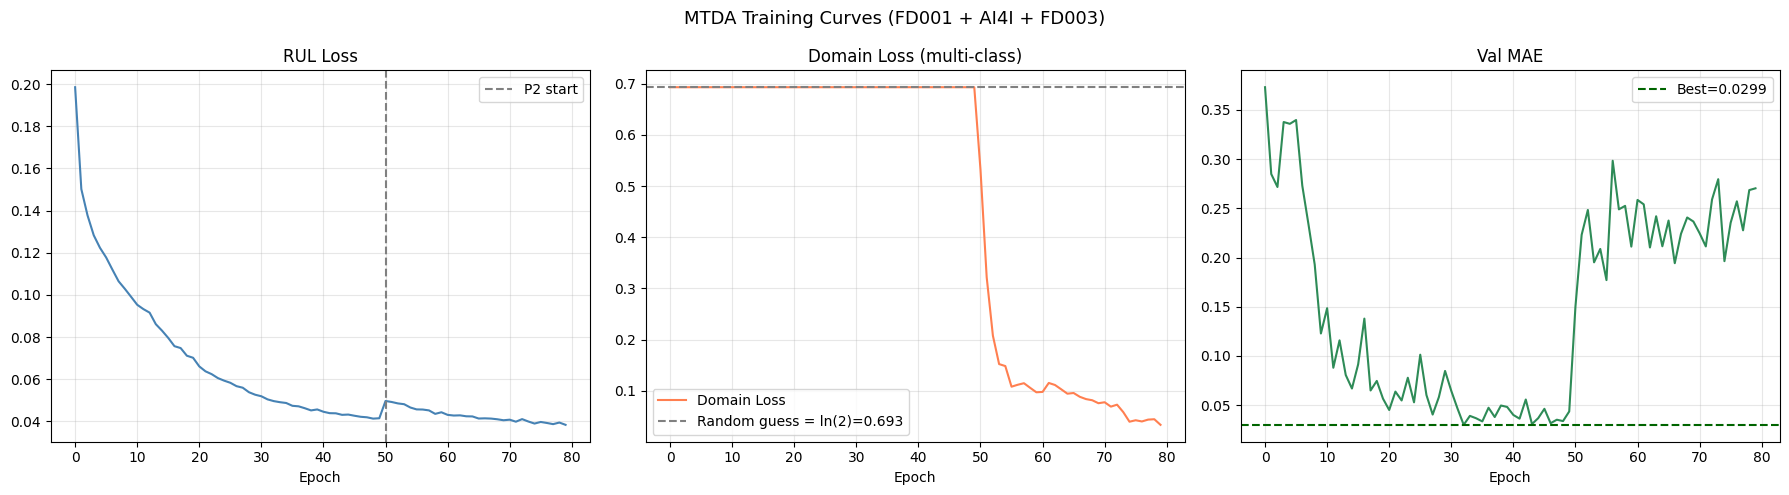


=== MTDA Cross-Domain Evaluation ===
  AI4I    : RMSE=45.95  MAE=36.73


In [58]:
# ── CELL 9: Evaluation and training curves ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(rul_losses, color='steelblue', linewidth=1.5)
axes[0].axvline(PHASE1_EPOCHS, color='gray', linestyle='--', label='P2 start')
axes[0].set_title('RUL Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(dom_losses, color='coral', linewidth=1.5, label='Domain Loss')
axes[1].axhline(np.log(N_DOMAINS), color='gray', linestyle='--',
                label=f'Random guess = ln({N_DOMAINS})={np.log(N_DOMAINS):.3f}')
axes[1].set_title('Domain Loss (multi-class)'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(val_maes, color='seagreen', linewidth=1.5)
axes[2].axhline(best_val_p2, color='darkgreen', linestyle='--',
                label=f'Best={best_val_p2:.4f}')
axes[2].set_title('Val MAE'); axes[2].set_xlabel('Epoch')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle('MTDA Training Curves (FD001 + AI4I + FD003)', fontsize=13)
plt.tight_layout(); plt.show()

# ── Cross-domain evaluation ───────────────────────────────────────────────────
print('\n=== MTDA Cross-Domain Evaluation ===')

# Build AI4I ground-truth RUL once, outside the loop
# FIX: merge max_wear into ai4i_s and use the merged frame for both columns
max_wear_per_row = ai4i_segmented.groupby('unit_id')['Tool wear [min]'].transform('max')
ai4i_rul_all     = (max_wear_per_row - ai4i_segmented['Tool wear [min]']
                    ).clip(upper=MAX_RUL).values

for name, X_tgt_all in target_windows.items():
    X_adapted = adapters[name].predict(
        X_tgt_all.astype(np.float32), verbose=0, batch_size=256
    )
    y_pred = reg_model.predict(
        X_adapted.astype(np.float32), verbose=0, batch_size=256
    ).flatten() * MAX_RUL

    if name == 'FD003':
        # y_fd003_raw is in normalised [0,1] — convert to cycle scale
        y_true_mtda = y_fd003_raw.astype(np.float32) 
    else:
        # AI4I: use the pre-built RUL array, trimmed to window count
        y_true_mtda = ai4i_rul_all[:len(y_pred)]

    n = min(len(y_pred), len(y_true_mtda))
    r = rmse(y_true_mtda[:n], y_pred[:n])
    m = mae(y_true_mtda[:n],  y_pred[:n])
    print(f'  {name:<8}: RMSE={r:.2f}  MAE={m:.2f}')
